<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Aprobación de Préstamos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

## 1. Configuración Inicial y Carga de Datos

En esta sección, importamos las librerías necesarias para el análisis de datos, el modelado y la visualización. Luego, cargamos el conjunto de datos de aprobación de préstamos desde un archivo CSV y realizamos una primera inspección para entender su estructura, estadísticas descriptivas y la presencia de valores nulos.

In [3]:
warnings.filterwarnings('ignore')

In [7]:
dk= pd.read_csv('/content/drive/MyDrive/CURSOPYTHON/train.csv')
print('----INFORME GENERA---')
display(dk.head())
print("\n--- Estadísticas Descriptivas Numéricas ---")
display(dk.describe())
print("\n--- Estadísticas Categóricas ---")
display(dk.describe(include='object'))
print('\n---- Ultimas 5 -----')
display(dk.tail(5))
display(dk.shape)

----INFORME GENERA---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



--- Estadísticas Descriptivas Numéricas ---


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



--- Estadísticas Categóricas ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422



---- Ultimas 5 -----


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


(614, 13)

## 2. Preprocesamiento y Limpieza de Datos

Aquí, se realiza la conversión de la columna `Loan_Status` de etiquetas categóricas ('Y', 'N') a numéricas (1, 0) para facilitar el modelado. También se elimina la columna `Loan_ID` ya que no es relevante para el entrenamiento del modelo. Se verifica la presencia de valores faltantes.

In [8]:
if dk['Loan_Status'].dtype== '0':
  dk['Loan_Status']= dk['Loan_Status'].map({'Y':1, 'N': 0})

dk= dk.drop('Loan_ID', axis=1, errors='ignore')


In [9]:
sns.set_theme(style='whitegrid')

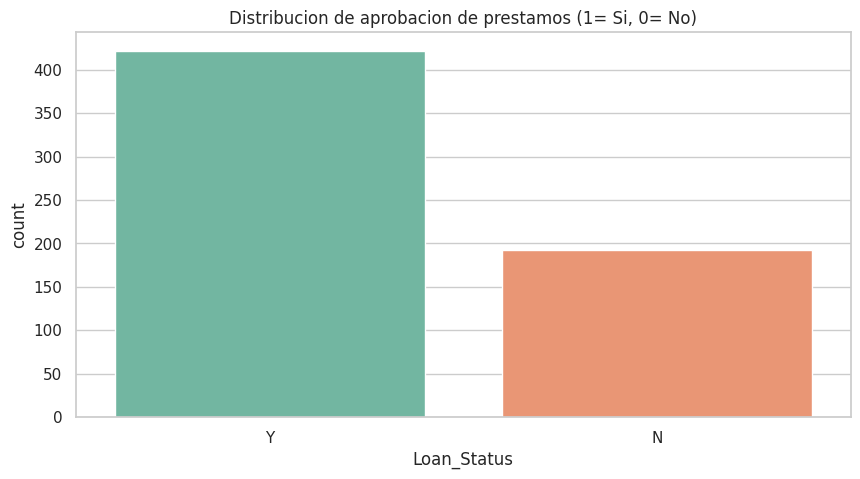

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(x='Loan_Status', data=dk, palette='Set2')
plt.title('Distribucion de aprobacion de prestamos (1= Si, 0= No)')
plt.show()

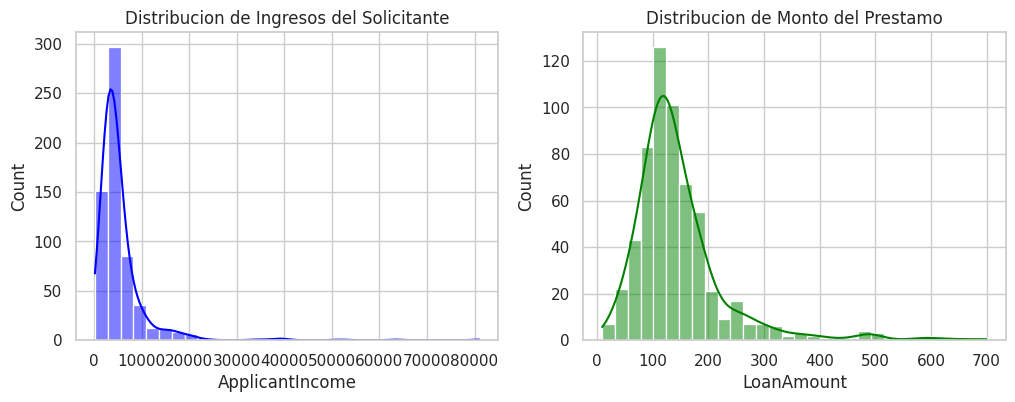

In [14]:
fig,axes= plt.subplots(1,2, figsize=(12,4))
sns.histplot(dk['ApplicantIncome'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribucion de Ingresos del Solicitante')
sns.histplot(dk['LoanAmount'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribucion de Monto del Prestamo')
plt.show()

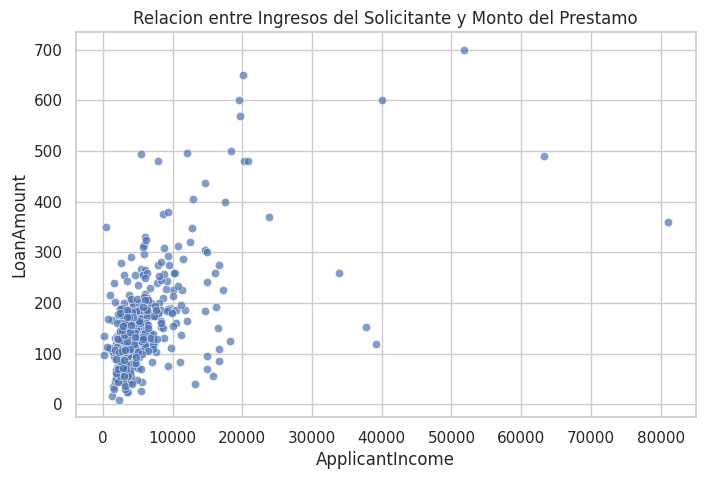

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=dk, alpha=0.7)
plt.title('Relacion entre Ingresos del Solicitante y Monto del Prestamo')
plt.show()

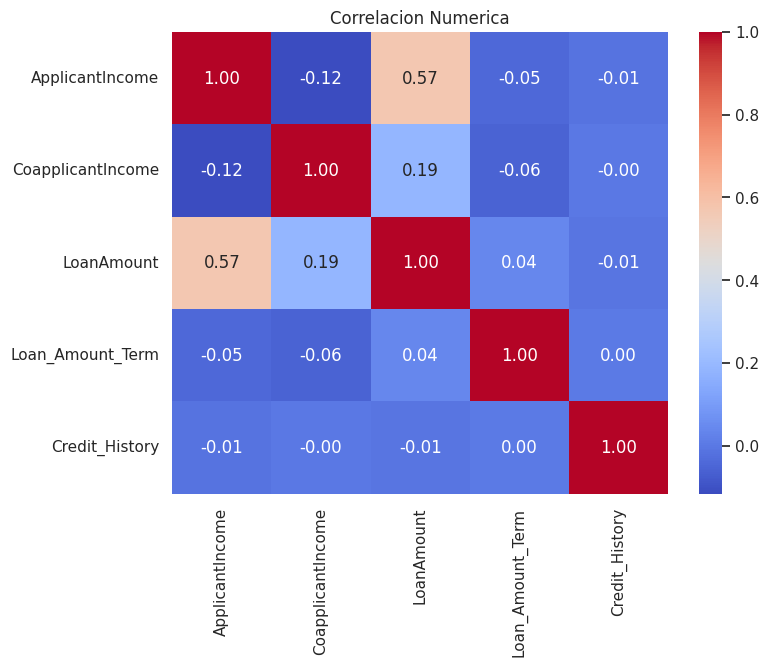

In [16]:
plt.figure(figsize=(8,6))
num_corr= dk.select_dtypes(include=[np.number]).corr()
sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlacion Numerica')
plt.show()

In [17]:
print("VALORES FALTANTEES")
print(dk.isnull().sum)

VALORES FALTANTEES
<bound method DataFrame.sum of      Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0     False    False       False      False          False            False   
1     False    False       False      False          False            False   
2     False    False       False      False          False            False   
3     False    False       False      False          False            False   
4     False    False       False      False          False            False   
..      ...      ...         ...        ...            ...              ...   
609   False    False       False      False          False            False   
610   False    False       False      False          False            False   
611   False    False       False      False          False            False   
612   False    False       False      False          False            False   
613   False    False       False      False          False            False   

 

## 3. Tratamiento de Outliers (Valores Atípicos)

Se aplica una técnica para limitar los valores atípicos en las columnas numéricas clave (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`) utilizando el rango intercuartílico (IQR). Los valores que exceden el límite superior (Q3 + 1.5 * IQR) se reemplazan por este límite.

In [18]:
for col in ['ApplicantIncome','CoapplicantIncome','LoanAmount']:
  q1= dk[col].quantile(0.25)
  q3= dk[col].quantile(0.75)
  iqr= q3 -q1
  limite_superior= q3 + 1.5*iqr
  dk[col]= np.where(dk[col]>limite_superior, limite_superior, dk[col])

## 4. Feature Engineering y Preparación para el Modelo

Esta sección se enfoca en la preparación de las características para el entrenamiento del modelo. Se definen transformadores para características numéricas (imputación por mediana y escalado) y categóricas (imputación por moda y codificación One-Hot). Luego, se crea un `ColumnTransformer` para aplicar estas transformaciones a los datos, y finalmente, los datos se dividen en conjuntos de entrenamiento y prueba.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [31]:
x=dk.drop('Loan_Status', axis=1)
y=dk['Loan_Status']

# Ensure y is numerical (0 and 1)
y = y.map({'Y': 1, 'N': 0})

numeric_features = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns

numeric_tranformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore',drop='first'))
])

preprocessor= ColumnTransformer(transformers=[
    ('num', numeric_tranformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

x_trai_proc= preprocessor.fit_transform(x_train)
x_test_proc= preprocessor.transform(x_test)

## 5. Modelado: LightGBM y Optimización de Hiperparámetros

Se entrena un modelo base LightGBM y se evalúa su rendimiento inicial. Posteriormente, se realiza una búsqueda de hiperparámetros utilizando `GridSearchCV` para encontrar la mejor combinación de parámetros que optimice la precisión del modelo. Finalmente, se comparan las métricas de rendimiento (Exactitud, Precisión, Recall, F1-Score, ROC-AUC) entre el modelo base y el modelo optimizado.

In [28]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

In [32]:
lgbm_base = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgbm_base.fit(x_trai_proc, y_train)

y_pred_base_str = lgbm_base.predict(x_test_proc)
y_prob_base = lgbm_base.predict_proba(x_test_proc)[:, 1]

y_pred_base = np.where(y_pred_base_str == 'Y', 1, 0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [10, 20, 31],
    'subsample': [0.8, 1.0]
}

print("Iniciando búsqueda de hiperparámetros con GridSearchCV...")
grid_search = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_trai_proc, y_train)
lgbm_optimizado = grid_search.best_estimator_

print(f"\nMejores parámetros encontrados:\n{grid_search.best_params_}")

# Predicciones del modelo optimizado
y_pred_opt_str = lgbm_optimizado.predict(x_test_proc)
y_prob_opt = lgbm_optimizado.predict_proba(x_test_proc)[:, 1]

# Convert string predictions to numerical (0/1)
y_pred_opt = np.where(y_pred_opt_str == 'Y', 1, 0)

def calcular_metricas(y_real, y_pred, y_prob):
    return {
        'Exactitud (Accuracy)': accuracy_score(y_real, y_pred),
        'Precisión': precision_score(y_real, y_pred),
        'Recall (Sensibilidad)': recall_score(y_real, y_pred),
        'F1-Score': f1_score(y_real, y_pred),
        'ROC-AUC': roc_auc_score(y_real, y_prob)
    }

metricas_base = calcular_metricas(y_test, y_pred_base, y_prob_base)
metricas_opt = calcular_metricas(y_test, y_pred_opt, y_prob_opt)

df_metricas = pd.DataFrame([metricas_base, metricas_opt], index=['LGBM Base', 'LGBM Optimizado'])
print("\n--- Comparativa Final de Rendimiento ---")
display(df_metricas)

Iniciando búsqueda de hiperparámetros con GridSearchCV...

Mejores parámetros encontrados:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'num_leaves': 10, 'subsample': 0.8}

--- Comparativa Final de Rendimiento ---


,Exactitud (Accuracy),Precisión,Recall (Sensibilidad),F1-Score,ROC-AUC
LGBM Base,0.821138,0.853933,0.894118,0.873563,0.802167
LGBM Optimizado,0.853659,0.831683,0.988235,0.903226,0.821517
